In [4]:
# TODO: Import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Also set sns theme to 'whitegrid' and default figure size to (10,5)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10,5)
pd.set_option('display.max_columns', None)
print("Libraries loaded")

Libraries loaded


In [5]:
# TODO: Load the Auto-MPG dataset from the UCI repository URL below.
# Column names: ['mpg','cylinders','displacement','horsepower','weight',
#                'acceleration','model_year','origin','car_name']
# Missing values are marked with '?'
# URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
col_names = ['mpg','cylinders','displacement','horsepower','weight',
             'acceleration','model_year','origin','car_name']

df =pd.read_csv(url, sep=r"\s+", names=col_names, na_values="?") # TODO: read_csv with correct separator (\s+) and na_values

print("Shape:", df.shape)
df.head()


Shape: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [6]:
# TODO: Print df.info() to inspect dtypes and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    str    
dtypes: float64(5), int64(3), str(1)
memory usage: 28.1 KB


In [7]:
# TODO: Print df.describe() to view summary statistics
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [8]:
# TODO: Check and print missing values per column
print(df.isna().sum())
# Then drop all rows that contain NaN values (they are < 2% of data)
df = df.dropna()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64


In [9]:
# Check for duplicate rows
print("Number of duplicate rows:",df.duplicated().sum())
# Remove duplicate rows
df = df.drop_duplicates()
print("Duplicate rows after removal:", df.duplicated().sum())


Number of duplicate rows: 0
Duplicate rows after removal: 0


In [ ]:
# 1. Convert cylinders and model_year to category dtype
df['cylinders'] = df['cylinders'].astype('category')
df['model_year'] = df['model_year'].astype('category')
# 2. Map 'origin' from {1,2,3} to {'usa','europe','japan'}
df['origin'] = df['origin'].map({1: 'USA', 2: 'Europe', 3: 'Japan'}).astype('category')
# 3. Strip & lowercase 'car_name'
df['car_name'] = df['car_name'].str.strip().str.lower()


In [ ]:
# TODO: Create two lists:
# cat_cols — categorical column names (cylinders, origin, model_year)
cat_cols = ['cylinders', 'origin', 'model_year']
# num_cols — numerical column names (mpg, displacement, horsepower, weight, acceleration)
num_cols = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']

In [17]:
# TODO: Create 'mpg_level' column using pd.cut()
df['mpg_level'] = pd.cut(df['mpg'], bins=[0, 17, 29, df['mpg'].max()], labels=['low', 'medium', 'high'])
# TODO: Create 'car_brand' column by splitting 'car_name'
df['car_brand'] = df['car_name'].str.split().str[0]
print(df[['mpg', 'mpg_level', 'car_brand']].head())

    mpg mpg_level  car_brand
0  18.0    medium  chevrolet
1  15.0       low      buick
2  18.0    medium   plymouth
3  16.0       low        amc
4  17.0       low       ford


In [20]:

# TODO: Create 'car_company' by extracting the first word from 'car_name'
df['car_company'] = df['car_name'].str.split().str[0]
print(df[['car_name', 'car_company']].head())

                    car_name car_company
0  chevrolet chevelle malibu   chevrolet
1          buick skylark 320       buick
2         plymouth satellite    plymouth
3              amc rebel sst         amc
4                ford torino        ford


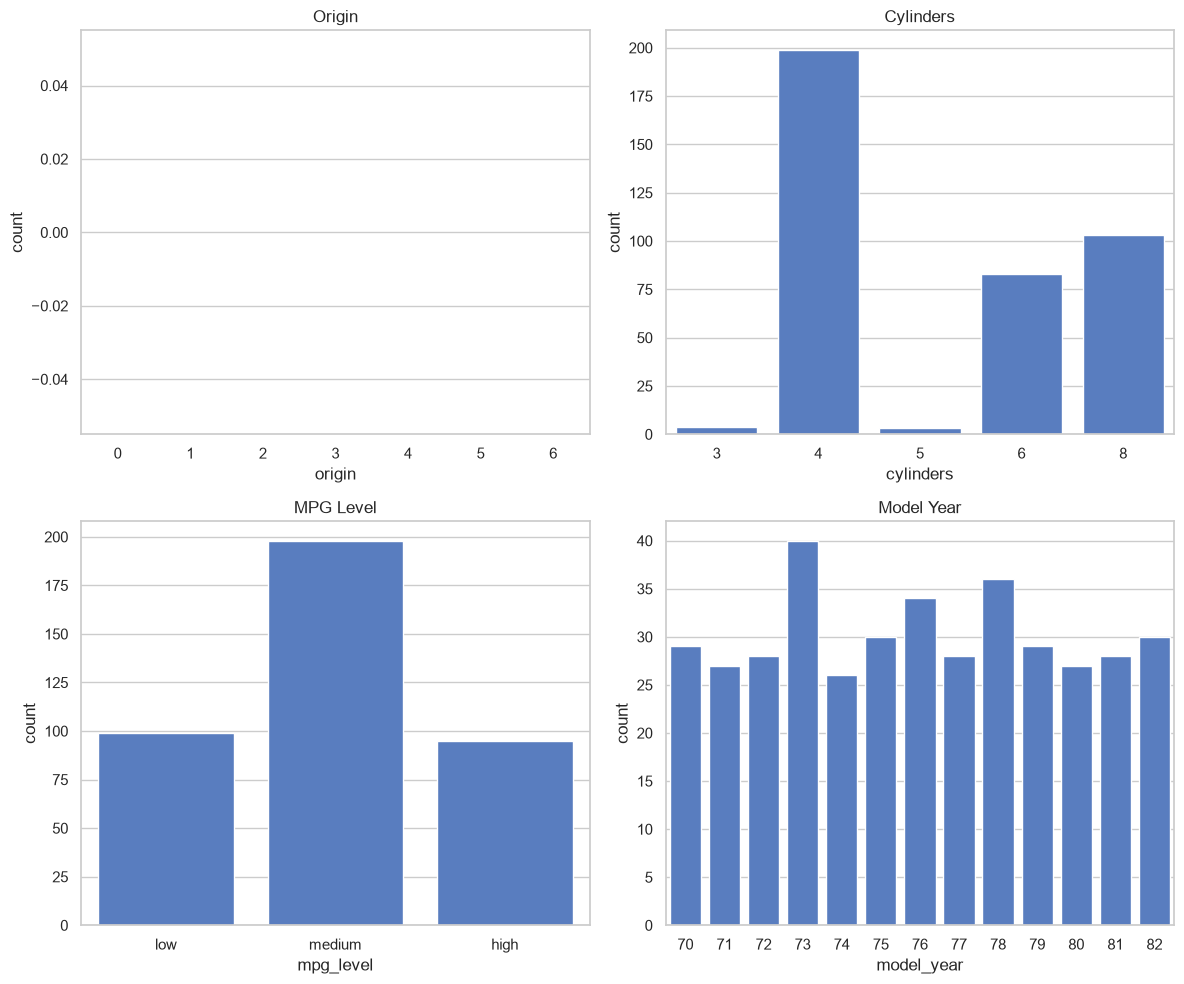

In [22]:
# TODO: Plot a countplot for each of: origin, cylinders, mpg_level, model_year
# Arrange them in a 2×2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.countplot(data=df, x='origin', ax=axes[0, 0])
axes[0, 0].set_title('Origin')
sns.countplot(data=df, x='cylinders', ax=axes[0, 1])
axes[0, 1].set_title('Cylinders')
sns.countplot(data=df, x='mpg_level', ax=axes[1, 0])
axes[1, 0].set_title('MPG Level')
sns.countplot(data=df, x='model_year', ax=axes[1, 1])
axes[1, 1].set_title('Model Year')
plt.tight_layout()
plt.show()


In [24]:
# TODO: Print the proportion (%) of the dominant class for
# origin, cylinders, and mpg_level
for col in ['origin', 'cylinders', 'mpg_level']:
    counts = df[col].value_counts()
    dominant_count = counts.max()
    proportion = (dominant_count / len(df)) * 100
    
    print(col, ":", round(proportion, 2), "%")

origin : nan %
cylinders : 50.77 %
mpg_level : 50.51 %


In [26]:
# TODO: Create a crosstab of cylinders vs origin and visualise as a bar chart
ct = pd.crosstab(df['cylinders'], df['origin'])
print(ct)

Empty DataFrame
Columns: []
Index: []


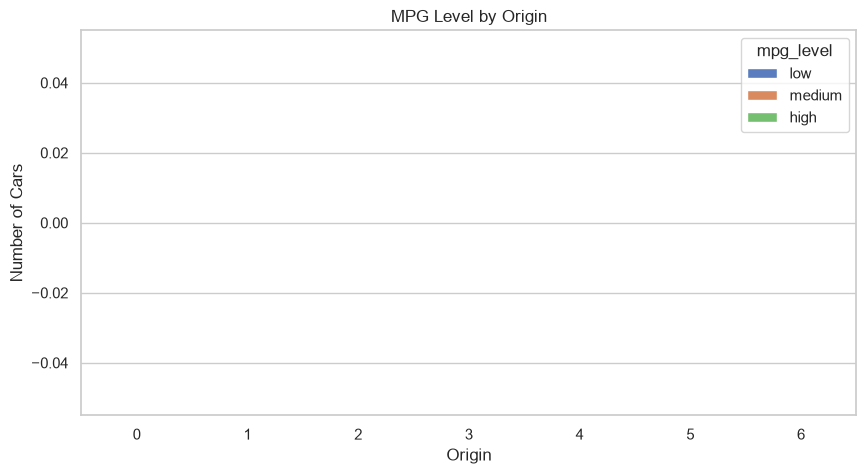

In [28]:
# TODO: Plot a countplot of mpg_level grouped by origin (use hue='mpg_level')
sns.countplot(data=df, x='origin', hue='mpg_level')

plt.title('MPG Level by Origin')
plt.xlabel('Origin')
plt.ylabel('Number of Cars')
plt.show()

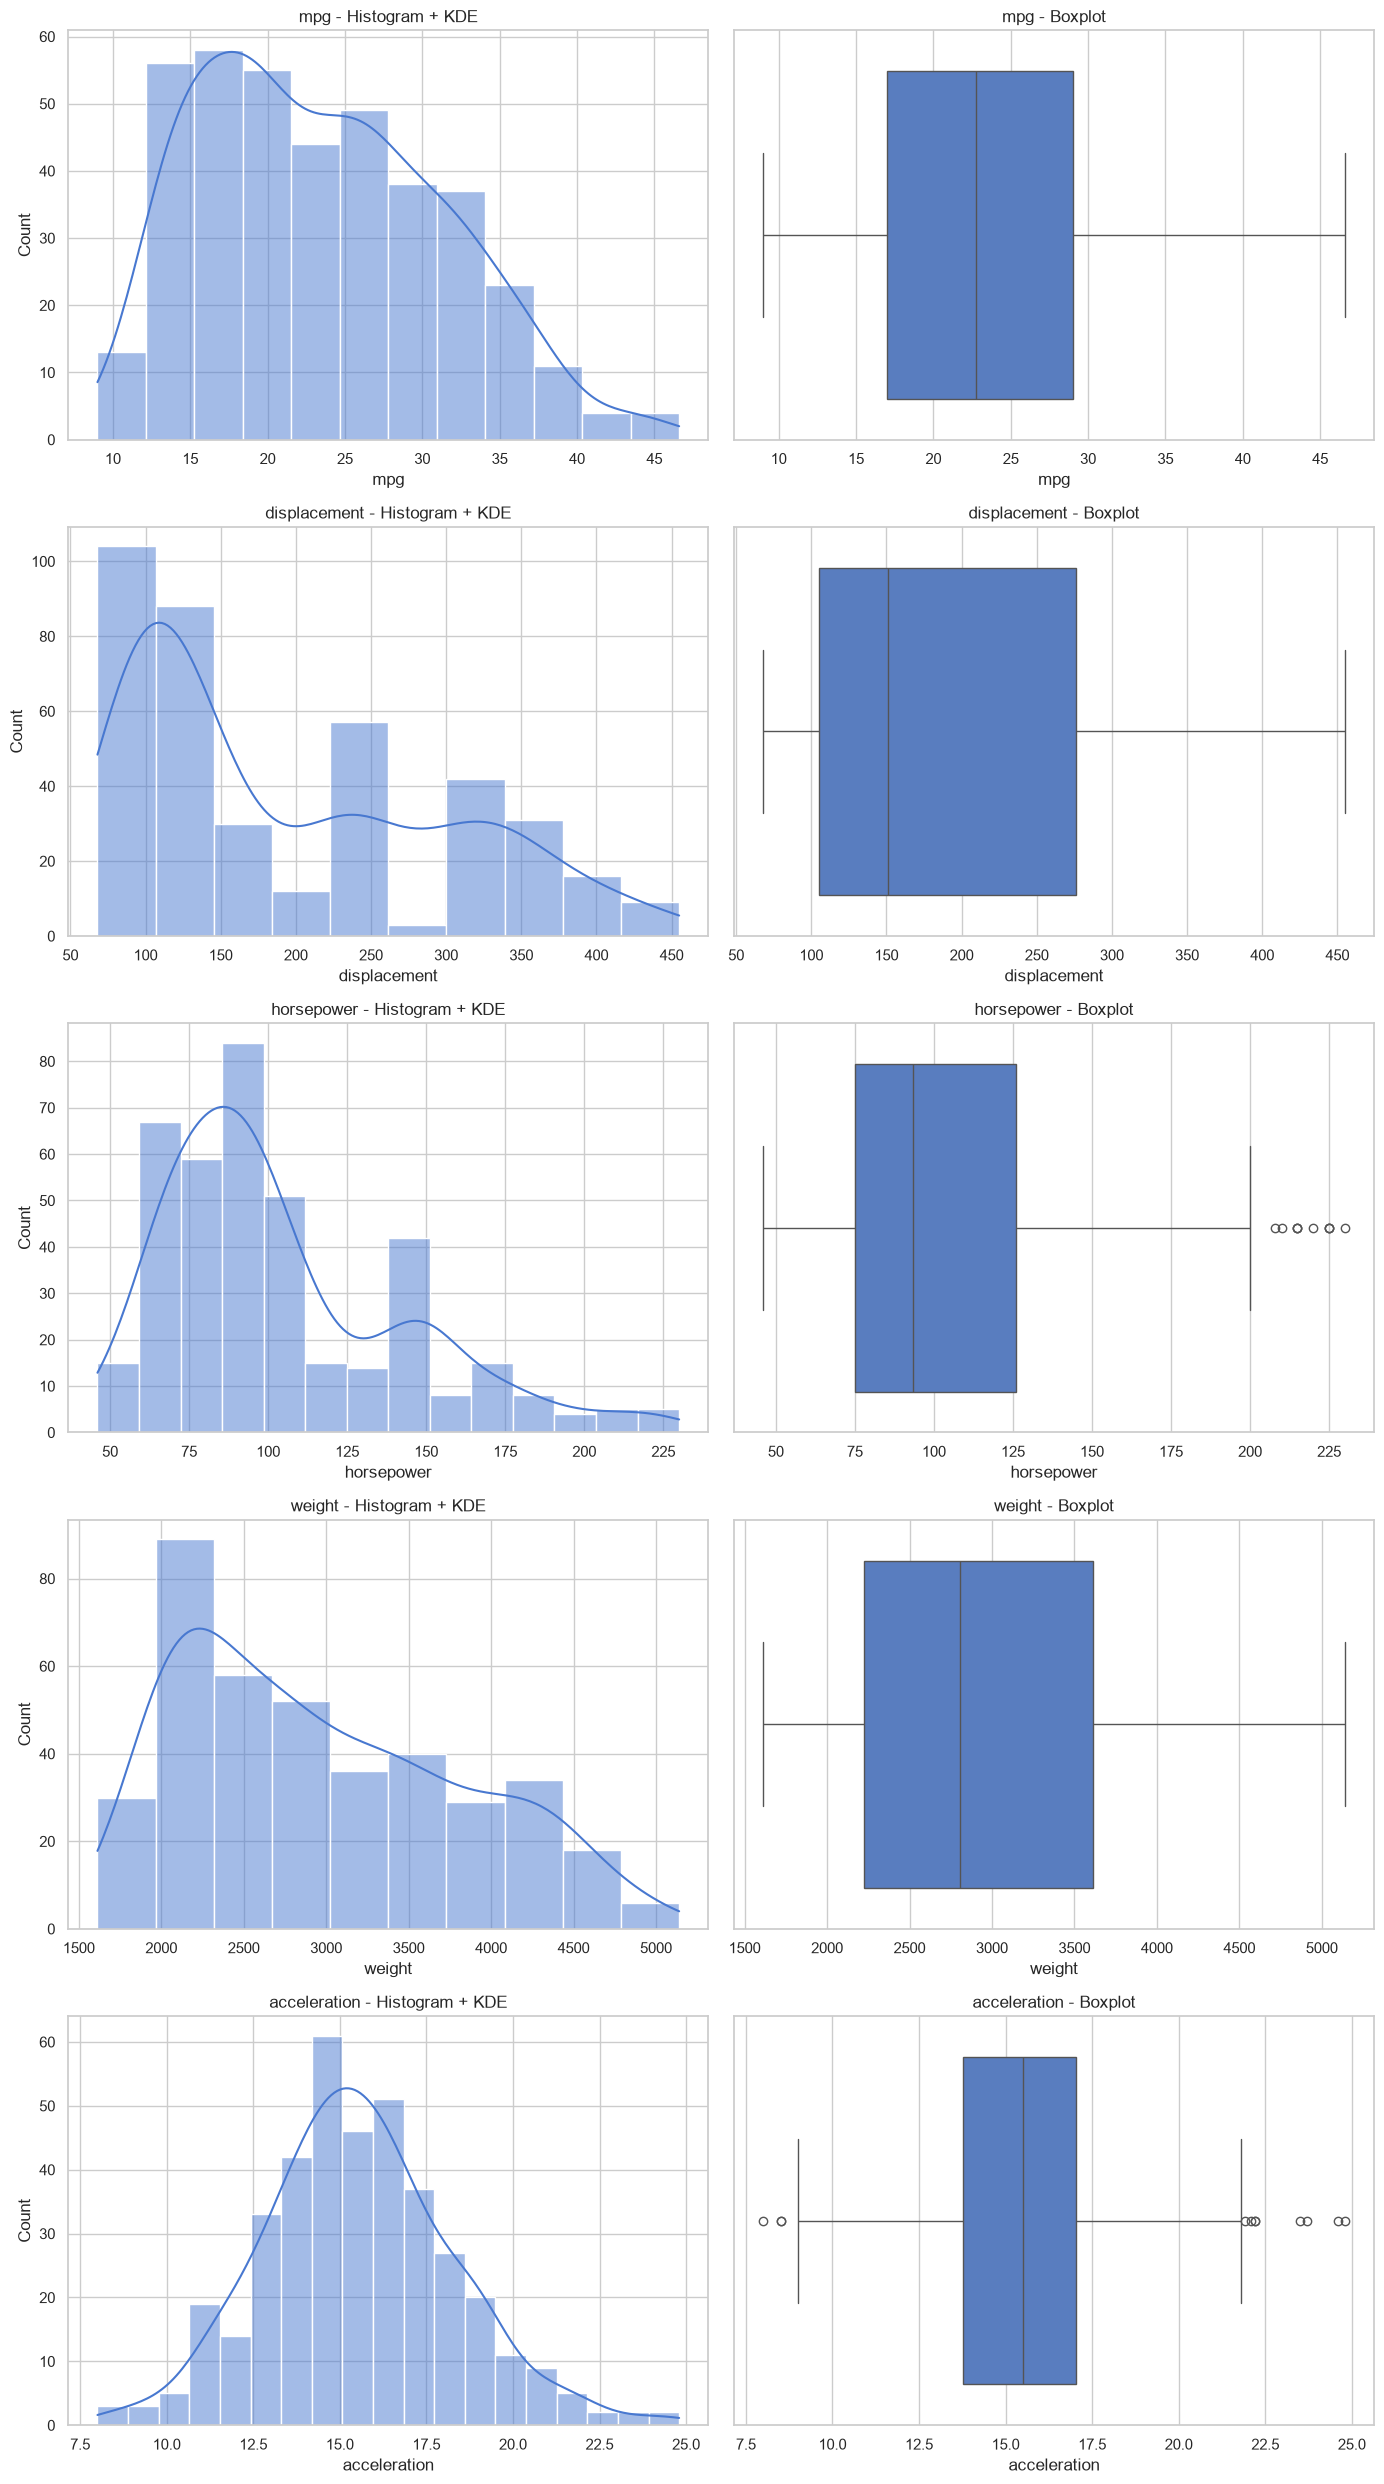

In [30]:
n_cols = len(num_cols)

fig, axes = plt.subplots(n_cols, 2, figsize=(14, 5 * n_cols))

for i, col in enumerate(num_cols):
    # (a) Histogram + KDE
    sns.histplot(data=df, x=col, kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'{col} - Histogram + KDE')

    # (b) Boxplot
    sns.boxplot(data=df, x=col, ax=axes[i, 1])
    axes[i, 1].set_title(f'{col} - Boxplot')

plt.tight_layout()
plt.show()

In [31]:
def tukey_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    
    return outliers

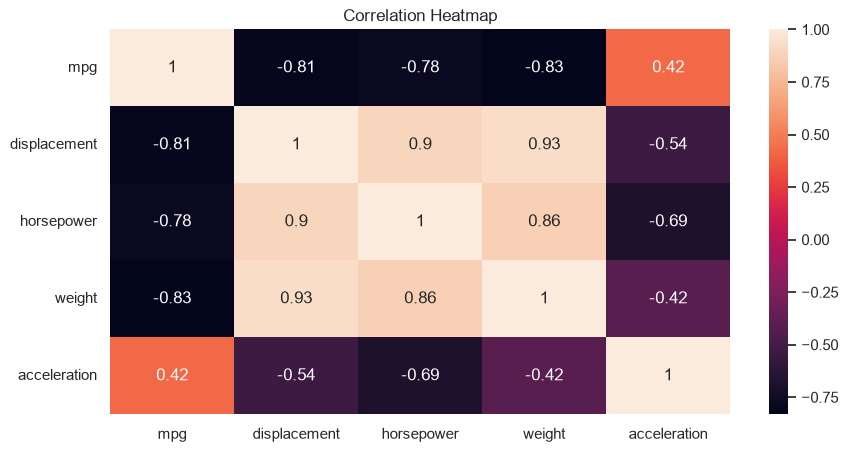

In [33]:
# TODO: Plot a correlation heatmap for all numerical columns (use annot=True)
corr = df[num_cols].corr()

sns.heatmap(corr, annot=True)

plt.title('Correlation Heatmap')
plt.show()

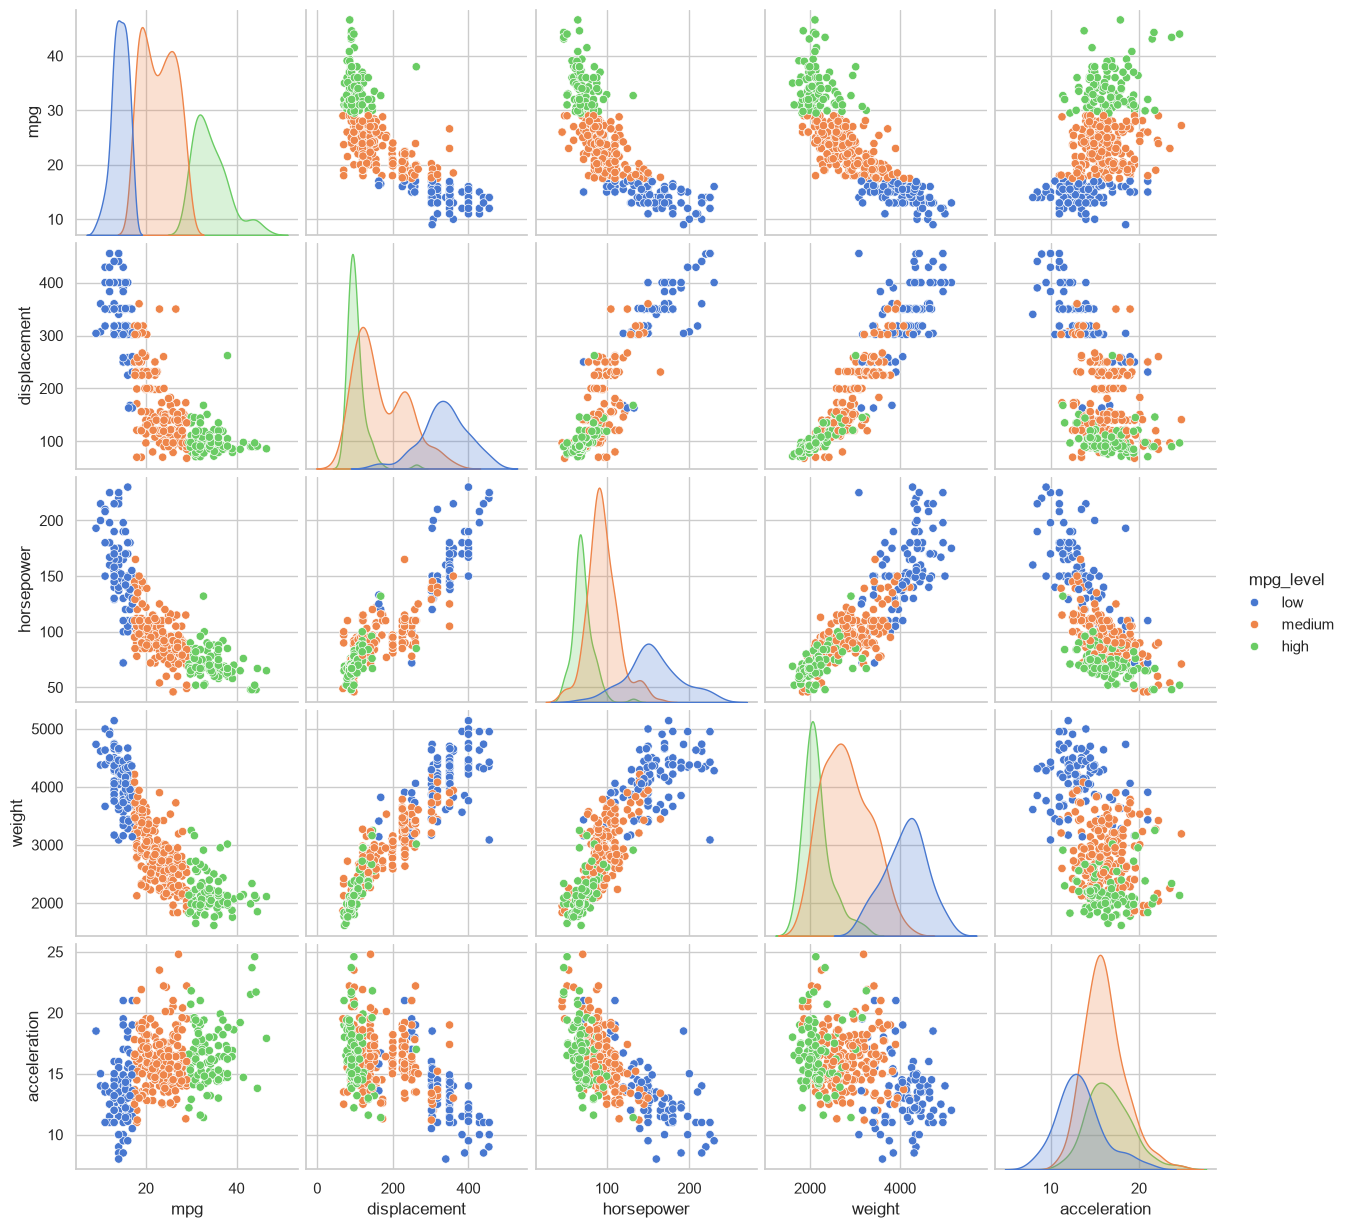

In [35]:
sns.pairplot(
    df,
    vars=num_cols,
    hue='mpg_level'
)

plt.show()

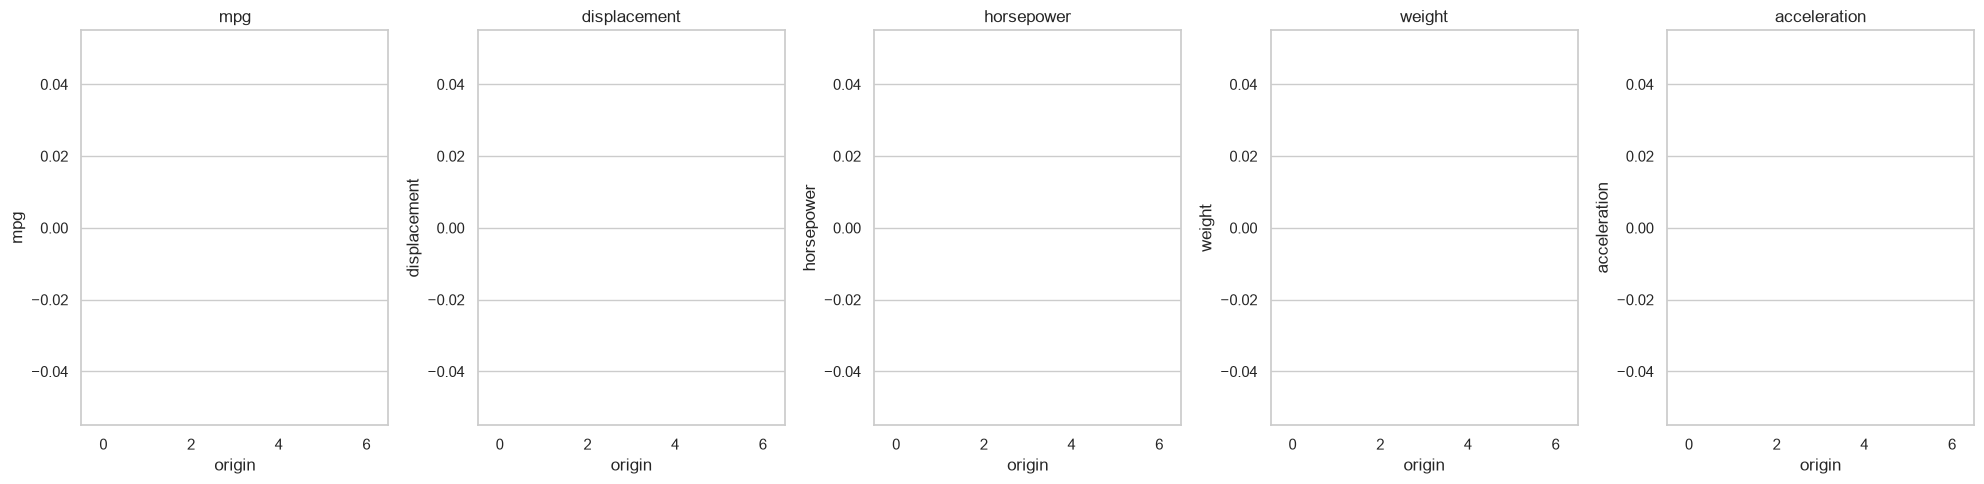

In [37]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, col in enumerate(num_cols):
    sns.boxenplot(data=df, x='origin', y=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

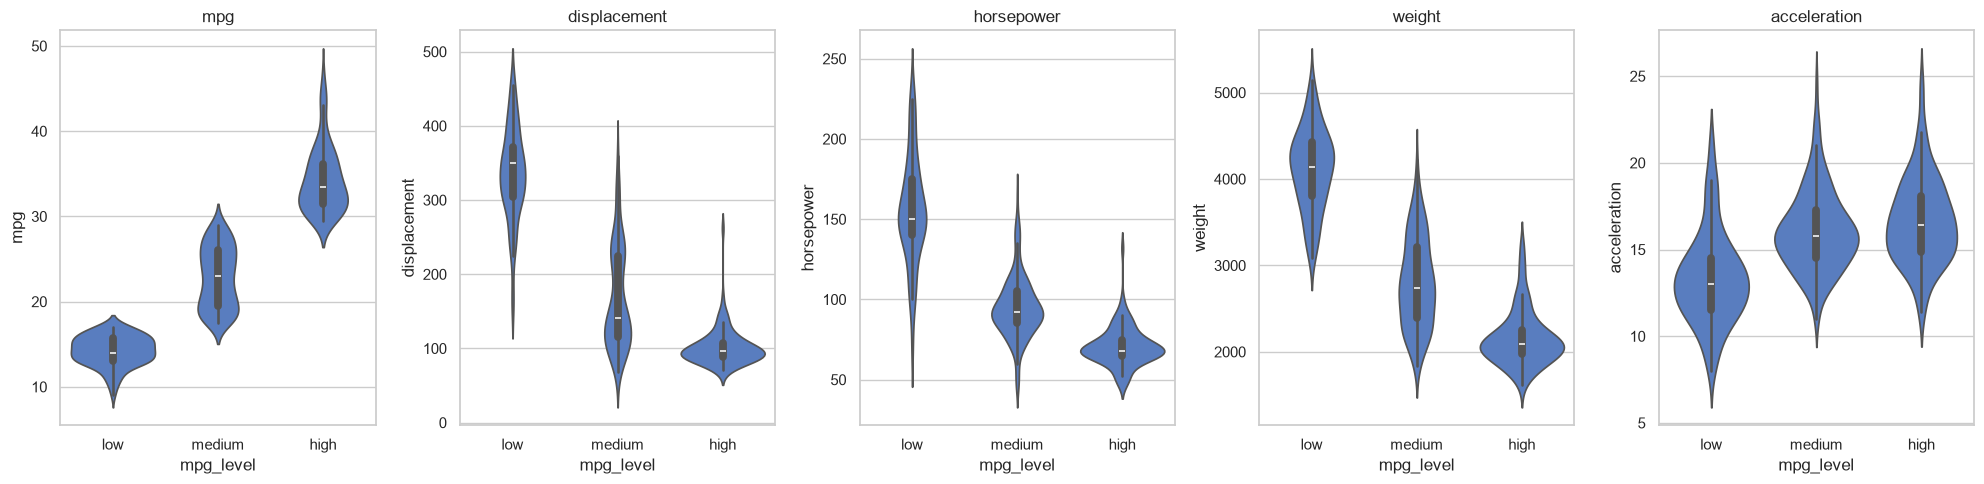

In [39]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, col in enumerate(num_cols):
    sns.violinplot(data=df, x='mpg_level', y=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

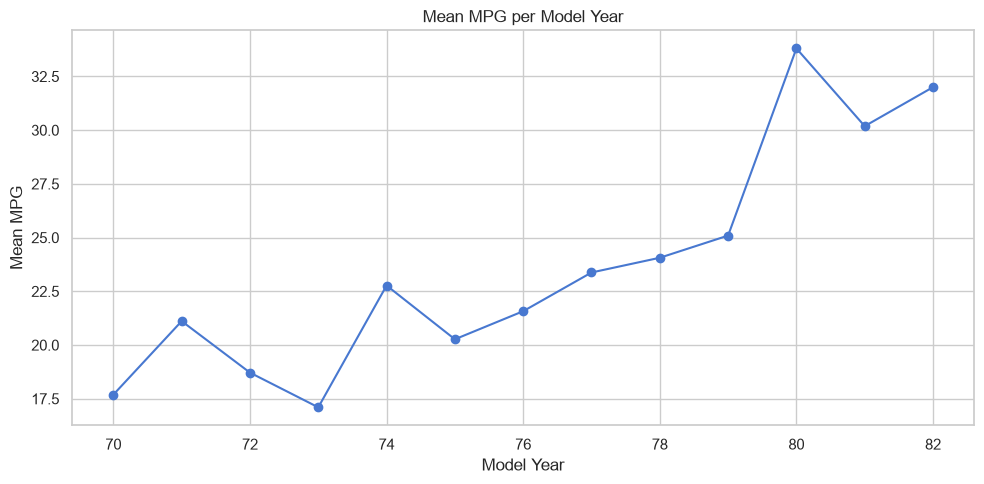

In [41]:
# TODO: Plot a line chart showing mean mpg per model_year
mean_mpg = df.groupby('model_year')['mpg'].mean()

plt.plot(mean_mpg.index, mean_mpg.values, marker='o')

plt.xlabel('Model Year')
plt.ylabel('Mean MPG')
plt.title('Mean MPG per Model Year')

plt.tight_layout()
plt.show()